In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install wordcloud matplotlib

In [3]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Data Analis Angkatan 2 Tahun 2026_Faneza Nur Mardania/21 Agustus 2026_Pertemuan 26/File Tugas/data_preprocessed2.csv')
df = df.dropna(subset=['teks_visual', 'sentimen'])

teks_positif = ' '.join(df.loc[df['sentimen'] == 'positif', 'teks_visual'])
teks_negatif = ' '.join(df.loc[df['sentimen'] == 'negatif', 'teks_visual'])

print('Total karakter positif:', len(teks_positif))
print('Total karakter negatif:', len(teks_negatif))

Total karakter positif: 133205
Total karakter negatif: 111852


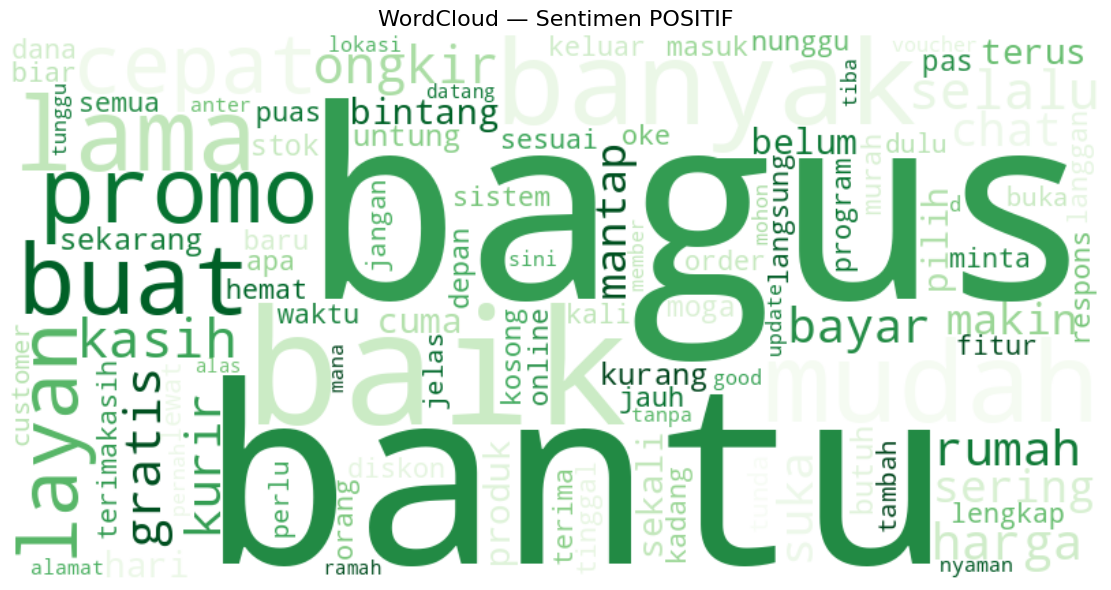

In [4]:

wc_pos = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=100,
    collocations=False
).generate(teks_positif)

plt.figure(figsize=(12, 6))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Sentimen POSITIF', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud_positif.png', dpi=150, bbox_inches='tight')
plt.show()



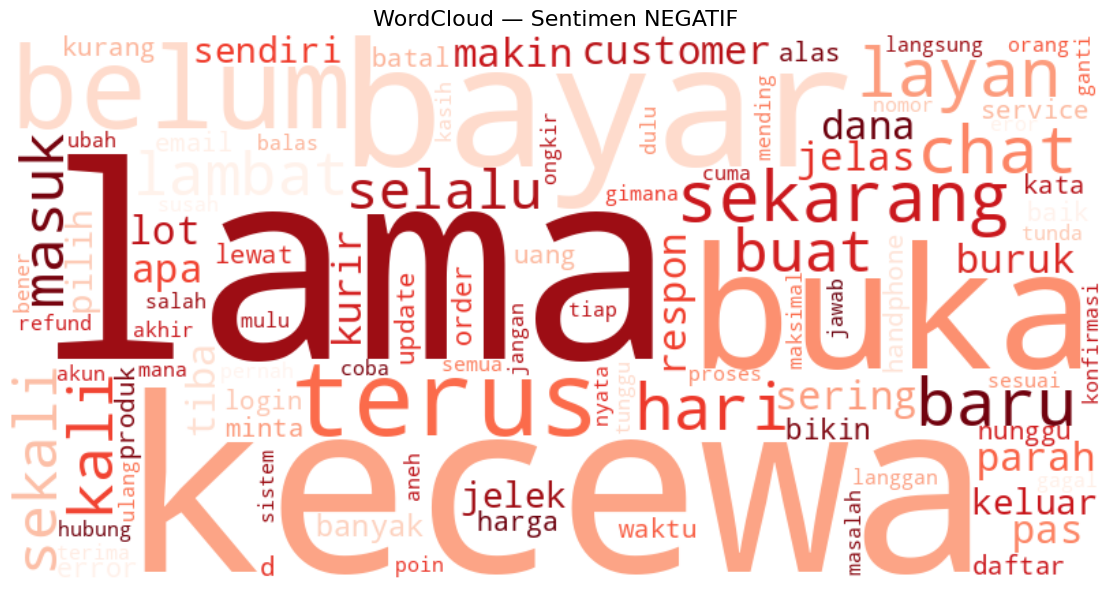

In [5]:

wc_neg = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=100,
    collocations=False
).generate(teks_negatif)

plt.figure(figsize=(12, 6))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Sentimen NEGATIF', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud_negatif.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
from collections import Counter

def top_words(teks, n=10):
    kata = teks.split()
    return Counter(kata).most_common(n)

top_pos = top_words(teks_positif, 10)
top_neg = top_words(teks_negatif, 10)

print('Top 10 kata POSITIF:')
for k, v in top_pos:
    print(f'  {k:15s} : {v}')

print('\nTop 10 kata NEGATIF:')
for k, v in top_neg:
    print(f'  {k:15s} : {v}')

Top 10 kata POSITIF:
  bagus           : 334
  bantu           : 298
  baik            : 274
  banyak          : 252
  mudah           : 231
  lama            : 191
  buat            : 172
  promo           : 171
  cepat           : 170
  layan           : 162

Top 10 kata NEGATIF:
  lama            : 259
  kecewa          : 209
  bayar           : 194
  buka            : 186
  belum           : 175
  terus           : 148
  sekarang        : 142
  layan           : 138
  baru            : 132
  chat            : 130


In [7]:
# from PIL import Image
# import numpy as np
# mask = np.array(Image.open('mask_hati.png'))

# wc = WordCloud(background_color='white', mask=mask,
#                colormap='Greens', contour_color='steelblue',
#                contour_width=2).generate(teks_positif)
# plt.imshow(wc, interpolation='bilinear')
# plt.axis('off')